# Convolutional Networks
### This node contains both forward and backward propagation


# regularization
- N : number of training examples or batch size
- L : number of conv layers
- $FC_l$ : fully connected layer l, marked as `FC_l` in code
---
- $X^{l}$: input of layer l, shape $(N, X_C^{l}, X_H^{l}, X_W^{l})$, marked as `X^{l}` in code
- $X_{col}^{l}$: img2col($X^{l}$), shape $(N\times Z_H^{l}\times Z_W^{l}, f_C^{l}\times f_{size}^{l}\times f_{size}^{l})$, marked as `X_{col}^{l}` in code
    
    - $X_W^{l}$: width of input of layer l, marked as `X_W^{l}` in code
    - $X_H^{l}$: height of input of layer l, marked as `X_H^{l}` in code
    - $X_C^{l}$: channel of input of layer l, marked as `X_C^{l}` in code

---
- $F_{col}^{l}$: filters, shape $(f_C^{l}\times f_{size}^{l}\times f_{size}^{l}, f_n^{l})$
    - $f_n^{l}$: number of filters in conv layer l, marked as `f_n^{l}` in code
    - $f_{size}^{l}$: filter size in conv layer l, marked as `f_{size}^{l}` in code
    - $f_c^{l}$: filter channel in conv layer l, marked as `f_c^{l}` in code
    - $f_p^{l}$: padding of filters in conv layer l, marked as `f_p^{l}` in code
    - $f_s^{l}$: stride of filters in conv layer l, marked as `f_s^{l}` in code
- $b^{l}$: bias of conv layer l, shape $(1, f_n^{l})$, marked as `b^{l}` in code
---
- $Z_W^{l}$: output size of conv layer l, $Z_W^{l} = \lfloor \frac{X_W^{l} + 2f_p^{l} - f_{size}^{l}}{f_s^{l}} \rfloor + 1$, marked as `Z_W^{l}` in code
- $Z_H^{l}$: output size of conv layer l, $Z_H^{l} = \lfloor \frac{X_H^{l} + 2f_p^{l} - f_{size}^{l}}{f_s^{l}} \rfloor + 1$, marked as `Z_H^{l}` in code
- $Z_C^{l}$: output channel of conv layer l, $Z_C^{l} = f_n^{l}$, marked as `Z_C^{l}` in code
---
- $A_W^{l}$: output of activation layer l, $A_W^{l} = Z_W^{l}$, marked as `A_W^{l}` in code
- $A_H^{l}$: output of activation layer l, $A_H^{l} = Z_H^{l}$, marked as `A_H^{l}` in code
- $A_C^{l}$: output channel of activation layer l, $A_C^{l} = Z_C^{l}$, marked as `A_C^{l}` in code
---
- $P_{size}^{l}$: padding of conv layer l, marked as `P_{size}^{l}` in code
- $P_p^{l}$: padding of conv layer l, marked as `P_p^{l}` in code
- $P_s^{l}$: stride of conv layer l, marked as `P_s^{l}` in code
- $P_C^{l}$: padding of conv layer l, $P_C^{l} = 1$, marked as `P_C^{l}` in code  
---
- $A^{FC_l}$: input of fully connected layer l, shape $(N, D^{FC_l})$, marked as `A^{FC_0}` in code
    - $D^{FC_l}$ : $Z_W^{l} \times Z_H^{l} \times Z_C^{l}$
    - $A^{FC_0}$.shape is equal to $X^{L}$.shape
- $A_{col}^{FC_l}$: img2col($A^{FC_l}$), shape $(N\times f_n^{l}\times X_H^{l}\times X_W^{l},P_C^{l}\times P_H^{l}\times P_W{l})$
---
- $Z^{FC_l}$: output of fully connected layer l, shape $(D^{FC_l},D^{FC_{l+1}})$, marked as `Z^{FC_l}` in code




In [23]:
import numpy as np
from numpy.lib.stride_tricks import as_strided
import matplotlib.pyplot as plt
import os

In [24]:
def img2col(X:np.ndarray, filter_size:int, stride:int = 1, padding:tuple[int,int]=(0,0), dilation:int = 1)->np.ndarray:
    '''
    X: (N,X_C,X_H,X_W)
    filter_size: (f_H,f_W) or f_size
    stride: f_s
    padding: (p_H,p_W)
    # return (N * h_out * w_out, X_C * filter_size * filter_size)
    return (N,h_out,w_out,C,filter_size,filter_size)
    '''
    N,C,H,W = X.shape # C == filter_c
    # if C!=filter_c:
    #     raise ValueError(f"img2col:channel of X({C}) is not match with channel of filter({filter_c})")
    h_out = (W + 2*padding[0] - filter_size) // stride + 1
    w_out = (H + 2*padding[1] - filter_size) // stride + 1

    p_h, p_w = padding
    if p_h > 0 or p_w > 0:
        X_paded = np.pad(X, [(0,0), (0,0), (p_h, p_h), (p_w, p_w)], mode='constant')
    else:
        X_paded = X

    new_shape = (N,h_out,w_out,C,filter_size,filter_size)
    # print(new_shape)

    # s_n = C*H*W, s_c = H*W, s_h = W, s_w = 1
    s_n,s_c,s_h,s_w = X_paded.strides
    new_strides = (s_n, # N
                   s_h*stride, # h_out
                   s_w*stride, # w_out
                   s_c, # C
                   s_h, # f_H
                   s_w) # f_W
    X_out = as_strided(X_paded,shape=new_shape,strides=new_strides) # (N,h_out,w_out,filter_c,filter_size,filter_size)
    return X_out



In [25]:
def col2img(X_col:np.ndarray, stride:int=1, padding:tuple=(0,0))->np.ndarray:
    '''
    Vectorized col2img (optimized loop over filter dimensions only)
    X_col: (N, h_out, w_out, X_C, filter_size, filter_size)
    return (N, X_C, X_H, X_W)
    '''
    N, h_out, w_out, C, filter_size, _ = X_col.shape
    p_h, p_w = padding
    
    # Calculate output dimensions
    H = (h_out - 1) * stride - 2 * p_h + filter_size
    W = (w_out - 1) * stride - 2 * p_w + filter_size
    
    # Calculate padded dimensions
    H_padded = H + 2 * p_h
    W_padded = W + 2 * p_w
    
    # Initialize output array (padded)
    X_padded = np.zeros((N, C, H_padded, W_padded), dtype=X_col.dtype)
    
    # Loop only over filter dimensions (e.g. 2x2 or 3x3), which is very small
    for fh in range(filter_size):
        for fw in range(filter_size):
            # Extract values for this filter position across all images and all sliding windows
            val = X_col[:, :, :, :, fh, fw] # (N, h_out, w_out, C)
            
            # Calculate the corresponding slice in the output image
            h_start = fh
            h_end = fh + h_out * stride
            w_start = fw
            w_end = fw + w_out * stride
            
            # Add gradients to the corresponding positions
            # We transpose val to (N, C, h_out, w_out) to match X_padded layout
            X_padded[:, :, h_start:h_end:stride, w_start:w_end:stride] += val.transpose(0, 3, 1, 2)

    # Remove padding
    if p_h > 0 or p_w > 0:
        return X_padded[:, :, p_h:p_h+H, p_w:p_w+W]
    else:
        return X_padded

![Col2Img Animation](layer_viz/col2img_animation.gif)

![img](layer_viz/col2img.jpg)

### 统一接口

In [26]:
class layer:
    def forward_prop(self,X:np.ndarray)->np.ndarray:
        pass
    def backward_prop(self,dY:np.ndarray)->np.ndarray:
        pass
    def modified_hyperparam(self, learn_rate=None, _Adam=None, beta1=None, beta2=None, epsilon=None):
        pass
    

### 实现细节
- 这里通过长宽方向使用不同的padding以更好满足卷积操作

- reshape 改成 view

- no clip

In [27]:
class Conv(layer):
    def __init__(
            self, filter_num, filter_size, filter_channel, stride=1, 
            _Adam = 0, Adam_beta1=0.9, Adam_beta2=0.999, epsilon=1e-8,
            learn_rate=0.001):
        self.filter_num = filter_num
        self.filter_size = filter_size
        self.filter_channel = filter_channel
        self.stride = stride
        """ 
        (H + 2p - f) ≡ 0 mod s
        (W + 2p - f) ≡ 0 mod s
        推出：
        H - f ≡ -2p mod s
        W - f ≡ -2p mod s
        说明H和W必须mod s同余
        设计者必须仔细设计s以保证输出为整数
        或者，选择长宽不同的filter或者padding!!!
        """
        self.padding = None

        # initialize filters and bias
        self.F = np.random.randn(filter_channel * filter_size * filter_size, filter_num) / np.sqrt(filter_size * filter_size * filter_channel)
            # maybe more way to initialize filters
        self.bias = np.zeros((1, filter_num))  # (1, f_n^{l})
        # update everytime forward_prop is called
        self.X_col = None
        self.col_shape = None
        # update params
        self.epsilon = epsilon
        self.learn_rate = learn_rate
        # Adam optimizer
        self._Adam = _Adam
        self.Adam_beta1 = Adam_beta1
        self.Adam_beta2 = Adam_beta2
        
        self.S_F = np.zeros_like(self.F)
        self.V_F = np.zeros_like(self.F)
        self.S_bias = np.zeros_like(self.bias)
        self.V_bias = np.zeros_like(self.bias)
    
    def modified_hyperparam(self, learn_rate=None, _Adam=None, beta1=None, beta2=None, epsilon=None):
        self.learn_rate = learn_rate
        if _Adam is not None:
            self._Adam = _Adam
        if beta1 is not None:
            self.Adam_beta1 = beta1
        if beta2 is not None:
            self.Adam_beta2 = beta2
        if epsilon is not None:
            self.epsilon = epsilon
        
    def forward_prop(self, X:np.ndarray)->np.ndarray:
        ''' 
        X: (N, X_C^{l-1}, X_H^{l-1}, X_W^{l-1})
        F: (f_c^{l}*f_size^{l}*f_size^{l})
        Returns: (N, f_n^{l}, Z_H^{l}, Z_W^{l})
        '''
        N,C,H,W = X.shape
        # adjust padding dynamically
        # stride seted to odd number is best, ensuring padding's validaity
        if self.padding is None:
            helper = (H - self.filter_size)%self.stride - self.stride
            while (helper % 2 != 0):
                if (self.stride%2==0):break
                helper -= self.stride
            p_h = -helper // 2
            helper = (W - self.filter_size)%self.stride - self.stride
            while (helper % 2 != 0):
                if (self.stride%2==0):break
                helper -= self.stride
            p_w = -helper // 2
            self.padding = (p_h,p_w)

        self.X_col = img2col(X,filter_size=self.filter_size,stride=self.stride,padding=self.padding)
        # (N,h_out,w_out,filter_c,filter_size,filter_size)
        self.col_shape = self.X_col.shape # 每次forward_prop都要更新col_shape
        self.X_col = self.X_col.reshape(self.col_shape[0]*self.col_shape[1]*self.col_shape[2],-1) # (N * h_out * w_out, X_C^{l-1} * filter_size^{l} * filter_size^{l})
        
        Z = self.X_col @ self.F + self.bias # (N * Z_H^{l} * Z_W^{l}, f_n^{l})
        # Z = Z.reshape(shape[0],shape[1],shape[2],self.filter_num)# (N, Z_H^{l}, Z_W^{l}, f_n^{l})
        Z = Z.reshape(self.col_shape[0],self.col_shape[1],self.col_shape[2],self.filter_num)# (N, Z_H^{l}, Z_W^{l}, f_n^{l})
        # 下一层可能是任何一种层，所以要维护维度等于输入的维度
        return Z.transpose(0,3,1,2)# (N, f_n^{l}, Z_H^{l}, Z_W^{l})
    def backward_prop(self, d_Z:np.ndarray)->np.ndarray:
        '''
        d_Z: (N, f_n^{l}, Z_H^{l}, Z_W^{l}) (统一维度设计)
        F: (X_C^{l-1} * filter_size^{l} * filter_size^{l}, f_n^{l})
        Returns: (N, X_C^{l-1}, X_H^{l-1}, X_W^{l-1})
        '''
        d_Z = d_Z.transpose(0,2,3,1).reshape(-1,self.filter_num) # (N * Z_H^{l} * Z_W^{l}, f_n^{l})
        
        d_F = self.X_col.T @ d_Z # (X_C * filter_size * filter_size, f_n^{l})
        d_bias = d_Z.sum(axis=0,keepdims=True).reshape(1,-1) # (1,f_n^{l})
        # d_F = np.clip(d_F, -1, 1)
        # d_bias = np.clip(d_bias, -1, 1)
        d_X_col = d_Z @ self.F.T # (N * Z_H^{l} * Z_W^{l}, X_C * filter_size * filter_size)
        # calculating gradient must be earlier than updating params
        if self._Adam:
            self.V_F = self.Adam_beta1 * self.V_F + (1-self.Adam_beta1) * d_F # (X_C * filter_size * filter_size, f_n^{l})
            self.S_F = self.Adam_beta2 * self.S_F + (1-self.Adam_beta2) * np.power(d_F,2) # (X_C * filter_size * filter_size, f_n^{l})
            self.F = self.F - self.learn_rate * self.V_F / (np.sqrt(self.S_F) + self.epsilon) # (X_C * filter_size * filter_size, f_n^{l})
            self.V_bias = self.Adam_beta1 * self.V_bias + (1-self.Adam_beta1) * d_bias # (1,f_n^{l})
            self.S_bias = self.Adam_beta2 * self.S_bias + (1-self.Adam_beta2) * np.power(d_bias,2) # (1,f_n^{l})
            self.bias = self.bias - self.learn_rate * self.V_bias / (np.sqrt(self.S_bias) + self.epsilon) # (1,f_n^{l})
        else:
            self.F = self.F - self.learn_rate * d_F # (X_C * filter_size * filter_size, f_n^{l})
            self.bias = self.bias - self.learn_rate * d_bias # (1,f_n^{l})  
        d_X_col = d_X_col.reshape(self.col_shape) # (N, h_out, w_out, filter_c, filter_size, filter_size)
        d_X = col2img(d_X_col,stride=self.stride, padding=self.padding) # (N,X_C^{l-1}, X_H^{l-1}, X_W^{l-1}) 
        return d_X
        
        

In [28]:
class BatchNorm(layer):
    def __init__(self,
            _Adam = 0, Adam_beta1=0.9, Adam_beta2=0.999, epsilon=1e-8,
            learn_rate=0.001):
        self._Adam = _Adam
        self.Adam_beta1 = Adam_beta1
        self.Adam_beta2 = Adam_beta2
        self.epsilon = epsilon
        self.learn_rate = learn_rate

        
        self.input_shape = None

        # tmp params
        self.mu = None
        self.sigma = None
        self.y_hat = None
        self.y_tilde = None

        # learnable parameters
        self.gamma = None
        self.beta = None

        self.S_gamma = np.zeros_like(self.gamma)
        self.V_gamma = np.zeros_like(self.gamma)
        self.S_beta = np.zeros_like(self.beta)
        self.V_beta = np.zeros_like(self.beta)
        
    def modified_hyperparam(self, learn_rate=None, _Adam=None, beta1=None, beta2=None, epsilon=None):
        self.learn_rate = learn_rate
        if _Adam is not None:
            self._Adam = _Adam
        if beta1 is not None:
            self.Adam_beta1 = beta1
        if beta2 is not None:
            self.Adam_beta2 = beta2
        if epsilon is not None:
            self.epsilon = epsilon
    def forward_prop(self, Z:np.ndarray)->np.ndarray:
        # Z should be (N, ...)
        
        if self.input_shape is None:
            #  # For FC layers, shape is (N, D_out)
            # if len(Z.shape) == 2:
            #      # Parameter shape needs to broadcast with (N, D_out)
            #      # Gamma/Beta should be (1, D_out)
            #      self.input_shape = (1, Z.shape[1])
            # else:
            #     # For Conv layers (N, C, H, W)
            #     # Gamma/Beta should be (1, C, H, W) to broadcast
            #     self.input_shape = tuple([1] + list(Z.shape[1:]))
            self.input_shape = tuple([1]+list(Z.shape[1:]))
            
            
        if self.gamma is None:
            self.gamma = np.ones(self.input_shape)
        if self.beta is None:
            self.beta = np.zeros(self.input_shape)

        mu = Z.mean(axis=0, keepdims=True)
        sigma = np.var(Z, axis=0, keepdims=True)
        y_hat = (Z - mu) / np.sqrt(sigma + self.epsilon)
        y_tilde = self.gamma * y_hat + self.beta

        self.mu = mu
        self.sigma = sigma
        self.y_hat = y_hat
        self.y_tilde = y_tilde
        return y_tilde
    
    def backward_prop(self, d_y_tilde:np.ndarray)->np.ndarray:
        # Batch dimension is always axis 0 now
        axis = 0
        d_gamma = (d_y_tilde * self.y_hat).sum(axis=axis,keepdims=True) 
        d_beta = d_y_tilde.sum(axis=axis,keepdims=True)

        B = d_y_tilde.mean(axis=axis,keepdims=True)
        C = (d_y_tilde * self.y_hat).mean(axis=axis,keepdims=True)
        D = self.y_hat * C

        if self._Adam:
            self.V_gamma = self.Adam_beta1 * self.V_gamma + (1-self.Adam_beta1) * d_gamma
            self.S_gamma = self.Adam_beta2 * self.S_gamma + (1-self.Adam_beta2) * np.power(d_gamma,2)
            self.gamma = self.gamma - self.learn_rate * self.V_gamma / (np.sqrt(self.S_gamma) + self.epsilon)
            self.V_beta = self.Adam_beta1 * self.V_beta + (1-self.Adam_beta1) * d_beta
            self.S_beta = self.Adam_beta2 * self.S_beta + (1-self.Adam_beta2) * np.power(d_beta,2)
            self.beta = self.beta - self.learn_rate * self.V_beta / (np.sqrt(self.S_beta) + self.epsilon)
        else:
            self.gamma = self.gamma - self.learn_rate * d_gamma
            self.beta = self.beta - self.learn_rate * d_beta
        d_Z = (self.gamma / np.sqrt(self.sigma + self.epsilon)) * (d_y_tilde - B - D)
        return d_Z

In [29]:


class Activation(layer):
    def __init__(self, activation:str='relu'):
        self.activation = activation
        self.Z = None
        self.Map = None
        self.Indice = None
    def modified_hyperparam(self, learn_rate:float=0.001,
            _Adam:bool=False, beta1:float=0.9, beta2:float=0.999, epsilon:float=1e-8):
        pass
    @staticmethod
    def sigmoid(X:np.ndarray)->np.ndarray:
        # Numerically stable sigmoid
        X = X.clip(-100, 100)
        return np.where(X >= 0,
                       1 / (1 + np.exp(-X)),
                       np.exp(X) / (1 + np.exp(X)))
        # return 1 / (1 + np.exp(-X))
    def forward_prop(self, Z:np.ndarray)->np.ndarray:
        """
        Z: (N, ...)
        return: (N, ...) same as Z
        
        """
        self.Z = Z
        # to ensure activation function's emcapsulation, do not do reshape operation
        if self.activation == 'relu':
            self.Map = Z > 0
            return Z * self.Map
        elif self.activation == 'sigmoid':
            return self.sigmoid(Z)
        elif self.activation == 'softmax':
            if len(Z.shape) != 2: # (N, D_out)
                raise ValueError('FC layer softmax only support 2D input')
            # 对于语义分割，通常在通道维度进行softmax
            # 对于空间注意力，通常在H*W维度进行softmax
            exp_X = np.exp(Z - np.max(Z, axis=1, keepdims=True)) # 数值稳定版本
            self.Indice = exp_X / np.sum(exp_X, axis=1, keepdims=True)
            return self.Indice
        else:
            raise ValueError('activation must be relu or sigmoid or softmax')
    def backward_prop(self, d_A:np.ndarray)->np.ndarray:
        """
        d_A: (N, ...) same as Z
        return: (N, ...) same as Z
        """
        if self.activation == 'relu':
            d_Z = d_A * self.Map
        elif self.activation == 'sigmoid':
            sigmoid_z = self.sigmoid(self.Z)
            d_Z = sigmoid_z * (1 - sigmoid_z) * d_A
        elif self.activation == 'softmax':
            d_Z = (self.Indice - d_A) / self.Z.shape[0] # y_hat-y_onehot
            # d_Z = (self.Indice - d_A) # y_hat-y_onehot
        else:
            raise ValueError('activation must be relu or sigmoid')
        return d_Z
        

In [30]:
class Pooling(layer):# check
    def __init__(self,stride=1,
             pool_size=2,pool_type='max'):
        self.padding = None
        self.stride = stride
        self.pool_size = pool_size
        self.pool_type = pool_type
        
        self.onehot = None
        self.A_col = None
    def modified_hyperparam(self, learn_rate:float=0.001,
            _Adam:bool=False, beta1:float=0.9, beta2:float=0.999, epsilon:float=1e-8):
        pass
    def forward_prop(self,A:np.ndarray)->np.ndarray:
        """
        A: (N, f_n^{l}, Z_H^{l}, Z_W^{l})(统一维度设计)
        Returns: (N, f_n^{l}, h_out, w_out)(统一维度设计)
        """
        N, f_n, H, W = A.shape
        if self.padding is None:
            helper = (H - self.pool_size)%self.stride - self.stride
            while (helper % 2 != 0):
                if (self.stride%2==0):break
                helper -= self.stride
            p_h = -helper // 2
            helper = (W - self.pool_size)%self.stride - self.stride
            while (helper % 2 != 0):
                if (self.stride%2==0):break
                helper -= self.stride
            p_w = -helper // 2
            self.padding = (p_h,p_w)
        
        A = A.reshape(N*f_n, 1, H, W)  # (N*f_n, 1, H, W) # C = 1
        # Use img2col to extract pooling windows
        A_col = img2col(A, filter_size=self.pool_size, stride=self.stride, padding=self.padding) 
        # A_col: (N*f_n, h_out, w_out, 1, pool_size, pool_size)
        self.A_col_shape = A_col.shape
        
        # Flatten spatial dimensions: (N*f_n*h_out*w_out, pool_size*pool_size)
        A_col_flat = A_col.reshape(self.A_col_shape[0]*self.A_col_shape[1]*self.A_col_shape[2], -1) # (N*f_n*h_out*w_out, pool_size*pool_size)  
        
        # Apply pooling along the pooling window dimension (axis=1)
        if self.pool_type == 'max':
            X_flat = A_col_flat.max(axis=1)  # (N*f_n*h_out*w_out,)
            Indices = A_col_flat.argmax(axis=1)  # (N*f_n*h_out*w_out,)
            self.onehot = np.zeros(A_col_flat.shape)  # (N*f_n*h_out*w_out, pool_size*pool_size)
            self.onehot[np.arange(Indices.shape[0]), Indices] = 1 # (N*f_n*h_out*w_out, pool_size*pool_size)
            
        else:
            X_flat = A_col_flat.mean(axis=1)# (N*f_n*h_out*w_out,)
            self.onehot = None
        
        # Reshape back: (N, f_n, h_out, w_out)
        h_out, w_out = self.A_col_shape[1], self.A_col_shape[2]
        X = X_flat.reshape(N, f_n, h_out, w_out)

        
        return X  # (N, f_n, h_out, w_out)
    def backward_prop(self,d_X:np.ndarray)->np.ndarray:
        """
        d_X: (N, f_n^{l}, h_out, w_out)(统一维度设计)
        Returns: (N, f_n^{l}, H, W)
        """

        N, f_n, h_out, w_out = d_X.shape
        
        # Flatten d_X to match the pooled output shape
        d_X_flat = d_X.reshape(-1,1)  # (N*f_n*h_out*w_out,)
        
        # Create gradient array for A_col_flat: (N*f_n*h_out*w_out, pool_size*pool_size)
        pool_window_size = self.pool_size * self.pool_size
        
        if self.pool_type == 'max' and self.onehot is not None:
            d_A_col_flat = self.onehot * d_X_flat # (N*f_n*h_out*w_out, pool_size*pool_size)
        else:
            d_A_col_flat = d_X_flat / pool_window_size
        
        d_A_col = d_A_col_flat.reshape(N*f_n, h_out, w_out, 1, self.pool_size, self.pool_size)
        d_A = col2img(d_A_col,stride=self.stride, padding=self.padding) # (N*f_n, 1, H, W)
        return d_A.reshape(N, f_n, d_A.shape[2], d_A.shape[3]) # (N, f_n, H, W)
        
        
    

In [31]:
class FC(layer): # fully connected layer
    def __init__(self,output_size,
                _Adam = 0, Adam_beta1=0.9, Adam_beta2=0.999, epsilon=1e-8,
                learn_rate=0.001):
        self.input_size = None # default None, will be set in forward_prop
        self.output_size = output_size

        self.A = None
        self.shape = None

        self.W = None
        # bias shape (1, output_size) to broadcast with (output_size, N)
        self.b = np.zeros((1, output_size))

        # Adam optimizer
        self._Adam = _Adam
        self.Adam_beta1 = Adam_beta1
        self.Adam_beta2 = Adam_beta2
        self.epsilon = epsilon
        self.learn_rate = learn_rate
        
        self.S_W = None  # Will be initialized when W is created
        self.V_W = None
        self.S_b = np.zeros_like(self.b)
        self.V_b = np.zeros_like(self.b)

    def modified_hyperparam(self, learn_rate:float=0.001,
            _Adam:bool=False, beta1:float=0.9, beta2:float=0.999, epsilon:float=1e-8):
        self.learn_rate = learn_rate
        if _Adam is not None:
            self._Adam = _Adam
        if beta1 is not None:
            self.Adam_beta1 = beta1
        if beta2 is not None:
            self.Adam_beta2 = beta2
        if epsilon is not None:
            self.epsilon = epsilon
    def forward_prop(self,A:np.ndarray)->np.ndarray:
        """
        A: Can be (N, f_n^{l}, X_H^{l}, X_W^{l}) from conv/pool layers or (N, D_out_prev) from FC layers
        W: (D_in, D_out)
        return Z: (N, D_out)
        """
        self.shape = A.shape # (N, f_n^{l}, X_H^{l}, X_W^{l}) or (N, D_out_prev)
        if len(A.shape) == 4: # (N, C, H, W)
            # Flatten the input to (N, D_in)
            self.A = A.reshape(A.shape[0], -1)  # (N, D_in)
        elif len(A.shape) == 2: # (N, D_in)
            self.A = A
        else:
            raise ValueError(f"Unsupported input shape: {A.shape}. Expected 2D or 4D input.")

        if self.W is None:
            self.input_size = self.A.shape[1]
            self.W = np.random.randn(self.input_size,self.output_size) * np.sqrt(2/self.input_size)
            self.S_W = np.zeros_like(self.W)
            self.V_W = np.zeros_like(self.W)    

        Z = self.A @ self.W + self.b # (N, D_out)
        return Z
    def backward_prop(self,d_Z:np.ndarray)->np.ndarray:
        """
        d_Z: (N, D_out)
        return: (N, f_n^{l}, X_H^{l}, X_W^{l}) or (N, D_out_prev) same as A
        """
        d_W = self.A.T @ d_Z # (D_in, D_out)
        d_b = np.sum(d_Z,axis=0,keepdims=True) # (1, D_out)
        # d_W = np.clip(d_W, -1, 1)
        # d_b = np.clip(d_b, -1, 1)
        d_A = d_Z @ self.W.T  # (N, D_in)
        d_A = d_A.reshape(self.shape) # (N, H, W, C) or (N, D_out_prev)
        if self._Adam:
            self.V_W = self.Adam_beta1 * self.V_W + (1-self.Adam_beta1) * d_W # (D_in, D_out)
            self.S_W = self.Adam_beta2 * self.S_W + (1-self.Adam_beta2) * np.power(d_W,2) # (D_in, D_out)
            self.W = self.W - self.learn_rate * self.V_W / (np.sqrt(self.S_W) + self.epsilon) # (D_in, D_out)
            self.V_b = self.Adam_beta1 * self.V_b + (1-self.Adam_beta1) * d_b # (1, D_out)
            self.S_b = self.Adam_beta2 * self.S_b + (1-self.Adam_beta2) * np.power(d_b,2) # (1, D_out)
            self.b = self.b - self.learn_rate * self.V_b / (np.sqrt(self.S_b) + self.epsilon) # (1, D_out)
        else:
            self.W = self.W - self.learn_rate * d_W # (D_in, D_out)
            self.b = self.b - self.learn_rate * d_b # (1, D_out)

        return d_A # (N, f_n^{l}, X_H^{l}, X_W^{l})

In [32]:
class CNN:
    def __init__(self,layers:list[layer],
                learning_rate:float=0.001,
                _Adam:bool=False,beta1:float=0.9,beta2:float=0.999,epsilon:float=1e-8):
        self.layers = layers
        self.forward_params = []

        self.len = len(layers)

        self.learning_rate = learning_rate
        self._Adam = _Adam
        self.Adam_beta1 = beta1
        self.Adam_beta2 = beta2
        self.epsilon = epsilon

        self.cost_history = []
    
    def unified_hyperparam(self, learn_rate:float=0.001,
            _Adam:bool=False, beta1:float=0.9, beta2:float=0.999, epsilon:float=1e-8):
        for layer in self.layers:
            layer.modified_hyperparam(learn_rate, _Adam, beta1, beta2, epsilon)
        
    def forward(self,X:np.ndarray,Y:np.ndarray=None)->np.ndarray:
        self.forward_params = [X]  # Reset forward params for each forward pass
        for layer in self.layers:
            self.forward_params.append(layer.forward_prop(self.forward_params[-1]))
        return self.forward_params[-1]
    
    def calculate_cost(self, Y:np.ndarray)->float:
        """Calculate cross-entropy cost"""
        A_out = self.forward_params[-1]
        # Handle different output shapes
        if len(A_out.shape) == 4:  # (N, H, W, C)
            A_out = A_out.reshape(A_out.shape[0], -1)
        elif len(A_out.shape) == 2 and A_out.shape[0] != Y.shape[0]:  # (N, D_out)
            if A_out.shape[0] != Y.shape[0] and A_out.shape[1] == Y.shape[0]:
                A_out = A_out.T
        # Calculate cost
        Y_flat = Y.flatten()
        # Clip to prevent log(0)
        A_out = np.clip(A_out, 1e-15, 1.0 - 1e-15)
        cost = -np.mean(np.log(A_out[np.arange(Y_flat.shape[0]), Y_flat]))
        return cost
    
    def backward(self,dY:np.ndarray):
        for i in range(self.len-1,-1,-1):
            # !!!!!!!
            # if dY is None: # Add check for None gradient
            #      continue
            dY = self.layers[i].backward_prop(dY)
    
    def train(self,X:np.ndarray,Y:np.ndarray,epochs:int=1000,batch_size:int=32,tolerance:float=1e-6,print_cost:bool=True):
        N = X.shape[0]
        num_batches = N // batch_size + 1  # Ceiling division
        
        for i in range(epochs):
            # Shuffle data at the beginning of each epoch
            indices = np.random.permutation(N)
            X_shuffled = X[indices]
            Y_shuffled = Y[indices]
            
            epoch_cost = 0
            
            # Process in batches
            for batch_idx in range(num_batches):
                start_idx = batch_idx * batch_size
                end_idx = min(start_idx + batch_size, N)
                
                X_batch = X_shuffled[start_idx:end_idx]
                Y_batch = Y_shuffled[start_idx:end_idx]
                batch_size_actual = end_idx - start_idx
                
                # Clear the params
                self.forward_params = []

                # Forward pass
                self.forward(X_batch)
                
                # Calculate cost for this batch
                batch_cost = self.calculate_cost(Y_batch)
                if batch_cost and batch_idx %2 == 0:
                    print(f"Epoch {i} Batch {batch_idx} cost: {batch_cost:.6f}")
                epoch_cost += batch_cost
                
                # Calculate gradient for backward pass
                # For softmax cross-entropy: dA = (A - Y_onehot) / batch_size
                y_hat = self.forward_params[-1]
                
                # Handle different output shapes - convert to (N, D_out) format
                if len(y_hat.shape) == 4:  # (N, H, W, C)
                    y_hat = y_hat.reshape(y_hat.shape[0], -1)
                    num_classes = y_hat.shape[1]
                elif len(y_hat.shape) == 2:
                    # FC layer outputs (D_out, N) format
                    # The last FC layer should output (num_classes, batch_size)
                    if y_hat.shape[1] == batch_size_actual:
                        # It's (D_out, N) = (num_classes, batch_size), transpose to (N, D_out)
                        num_classes = y_hat.shape[0]  # Get num_classes before transpose
                        y_hat = y_hat.T  # Now (N, D_out) = (batch_size, num_classes)
                    elif y_hat.shape[0] == batch_size_actual:
                        # Already (N, D_out) = (batch_size, num_classes)
                        num_classes = y_hat.shape[1]
                    else:
                        raise ValueError(f"Unexpected output shape: {y_hat.shape}")
                else:
                    raise ValueError(f"Unexpected output shape: {y_hat.shape}")
                
                # Create one-hot encoding for Y_batch
                Y_onehot = np.zeros((batch_size_actual, num_classes)) # (N, D_out)
                Y_onehot[np.arange(batch_size_actual), Y_batch.flatten()] = 1
  
                # Backward pass
                self.backward(Y_onehot)
            
            # Average cost for the epoch
            if num_batches > 0:
                epoch_cost /= num_batches
                self.cost_history.append(epoch_cost)
                # 不适用学习率震荡更新， 依赖Adam优化器， 或者用learning rate decay
                self.learning_rate *= 0.95
                self.unified_hyperparam(learn_rate=self.learning_rate)
            
            if print_cost and i % 10 == 0:
                print(f'Cost after epoch {i}: {epoch_cost:.6f}')
            
            if i > 0 and len(self.cost_history) >= 2 and abs(self.cost_history[-1] - self.cost_history[-2]) < tolerance:
                print(f'Converged after {i} epochs')
                break
        return self.cost_history
    
    def predict(self, X:np.ndarray)->np.ndarray:
        """Make predictions on input data"""
        # Forward pass
        output = self.forward(X)

        # Handle different output shapes
        if len(output.shape) == 4:  # (N, H, W, C)
            output = output.reshape(output.shape[0], -1)
        elif len(output.shape) == 2:
             if output.shape[0] != X.shape[0] and output.shape[1] == X.shape[0]:
                 output = output.T

        # Return predicted classes (argmax)
        return np.argmax(output, axis=1).reshape(-1, 1)

    def evaluate(self, X:np.ndarray, Y:np.ndarray)->float:
        """Evaluate accuracy on test data"""
        predictions = self.predict(X)
        accuracy = np.mean(predictions == Y)
        return accuracy


        
        

In [33]:
# load t10k-images.idx3-ubyte
def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        data = f.read()
    return data
images = load_mnist_images('./data/MNIST/raw/t10k-images-idx3-ubyte')

# 16字节的文件头 + 10000张图片 * 28 * 28像素 = 7840016字节
images = np.frombuffer(images, np.uint8, offset=16).reshape(-1, 28*28)

# load t10k-labels.idx1-ubyte
def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        data = f.read()
    return data
labels = load_mnist_labels('./data/MNIST/raw/t10k-labels-idx1-ubyte')
# 8字节的文件头 + 10000个标签 = 10008字节
labels = np.frombuffer(labels, np.uint8, offset=8).reshape(-1, 1)



In [34]:
# 批量show
def show_images(images, labels, num_images=10, bias=0):
    plt.figure(figsize=(10, 1))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i + bias].reshape(28, 28), cmap='gray')
        plt.title(labels[i + bias][0])
        plt.axis('off')
    plt.show()


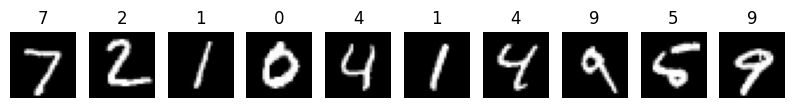

In [35]:
show_images(images, labels, num_images=10 ,bias = 0)

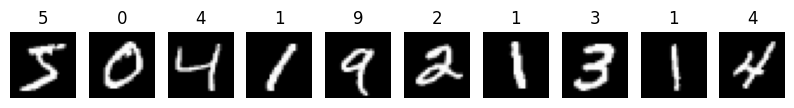

In [36]:
# load train-images.idx3-ubyte
images_train = load_mnist_images('./data/MNIST/raw/train-images-idx3-ubyte')
images_train = np.frombuffer(images_train, np.uint8, offset=16).reshape(-1, 28*28) #(N, 28*28)

# load train-labels.idx1-ubyte
labels_train = load_mnist_labels('./data/MNIST/raw/train-labels-idx1-ubyte')
# 8字节的文件头 + 60000个标签 = 10008字节
labels_train = np.frombuffer(labels_train, np.uint8, offset=8).reshape(-1, 1) #(N, 1)

show_images(images_train, labels_train, num_images=10 ,bias = 0)

In [37]:
print(type(images_train))
print(type(labels_train))
print(images_train.shape)
print(labels_train.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(60000, 784)
(60000, 1)


In [38]:
A = images_train.reshape(-1,28,28,1) # (N,28,28,1)
A = A.transpose(0,3,1,2) / 255.0# (N,1,28,28)
y_onehot = labels_train

# Prepare test data
A_test = images.reshape(-1,28,28,1) # (N,28,28,1)
A_test = A_test.transpose(0,3,1,2) # (N,1,28,28)
A_test = A_test / 255.0
y_test = labels

In [ ]:
cnn = CNN(layers=[
    Conv(filter_num=8, filter_size=3, filter_channel=1, stride=1, _Adam=1, learn_rate=0.01),
    Conv(filter_num=16, filter_size=3, filter_channel=8, stride=1, _Adam=1, learn_rate=0.01),
    BatchNorm(_Adam=1, learn_rate=0.01),
    Activation('relu'),
    Pooling(pool_size=3, stride=3),

    Conv(filter_num=32, filter_size=3, filter_channel=16, stride=1, _Adam=1, learn_rate=0.01),
    Conv(filter_num=64, filter_size=3, filter_channel=32, stride=1, _Adam=1, learn_rate=0.01),
    BatchNorm(_Adam=1, learn_rate=0.01),
    Activation('relu'),
    Pooling(pool_size=3, stride=3),# 尽量避免使用stride = 2,程序对于偶数stride可能无法补充padding

    FC(output_size=128, _Adam=1, learn_rate=0.01),
    BatchNorm(_Adam=1, learn_rate=0.01),
    Activation('relu'),
    FC(output_size=64, _Adam=1, learn_rate=0.01),
    BatchNorm(_Adam=1, learn_rate=0.01),
    Activation('relu'),
    FC(output_size=10, _Adam=1, learn_rate=0.01),
    Activation('softmax')
])
cost_history = cnn.train(X=A, Y=y_onehot, epochs=50, batch_size=1024)


Epoch 0 Batch 0 cost: 2.647349
Epoch 0 Batch 2 cost: 1.563296
Epoch 0 Batch 4 cost: 0.892288
Epoch 0 Batch 6 cost: 0.607838
Epoch 0 Batch 8 cost: 0.428472
Epoch 0 Batch 10 cost: 0.277057
Epoch 0 Batch 12 cost: 0.272095
Epoch 0 Batch 14 cost: 0.224775
Epoch 0 Batch 16 cost: 0.204329
Epoch 0 Batch 18 cost: 0.171058
Epoch 0 Batch 20 cost: 0.199503
Epoch 0 Batch 22 cost: 0.159812
Epoch 0 Batch 24 cost: 0.131339
Epoch 0 Batch 26 cost: 0.151324
Epoch 0 Batch 28 cost: 0.152752
Epoch 0 Batch 30 cost: 0.110520
Epoch 0 Batch 32 cost: 0.121134
Epoch 0 Batch 34 cost: 0.110885
Epoch 0 Batch 36 cost: 0.141896
Epoch 0 Batch 38 cost: 0.102747
Epoch 0 Batch 40 cost: 0.118433
Epoch 0 Batch 42 cost: 0.109187
Epoch 0 Batch 44 cost: 0.089467
Epoch 0 Batch 46 cost: 0.099822
Epoch 0 Batch 48 cost: 0.107456
Epoch 0 Batch 50 cost: 0.088771
Epoch 0 Batch 52 cost: 0.093326
Epoch 0 Batch 54 cost: 0.084872
Epoch 0 Batch 56 cost: 0.082935
Epoch 0 Batch 58 cost: 0.093320
Cost after epoch 0: 0.300391
Epoch 1 Batch 0 

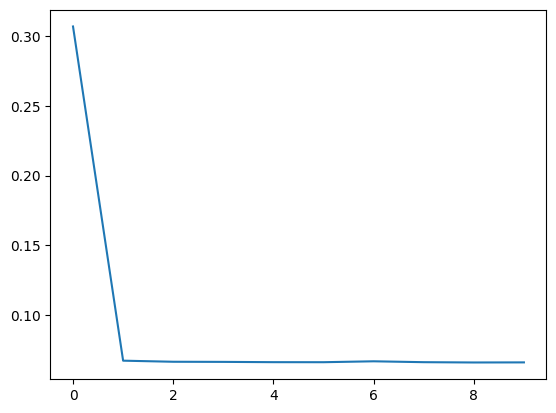

In [ ]:
# plot the cost history
plt.plot(cost_history)
plt.show()
plt.close()

In [ ]:

accuracy = cnn.evaluate(A_test, y_test)
print(f"Accuracy: {accuracy * 100:.5f}%")


Accuracy: 97.82000%
